In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/brent_oil_prices.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_9192\204352497.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9011 non-null   datetime64[ns]
 1   Price   9011 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 140.9 KB


,Date,Price
count,9011,9011.000000
mean,2005-02-10 23:46:53.760958720,48.420782
min,1987-05-20 00:00:00,9.100000
25%,1996-03-20 12:00:00,19.050000
50%,2005-02-02 00:00:00,38.570000
75%,2014-01-09 12:00:00,70.090000
max,2022-11-14 00:00:00,143.950000
std,NaN,32.860110


In [4]:
df.isnull().sum()

Date     0
Price    0
dtype: int64

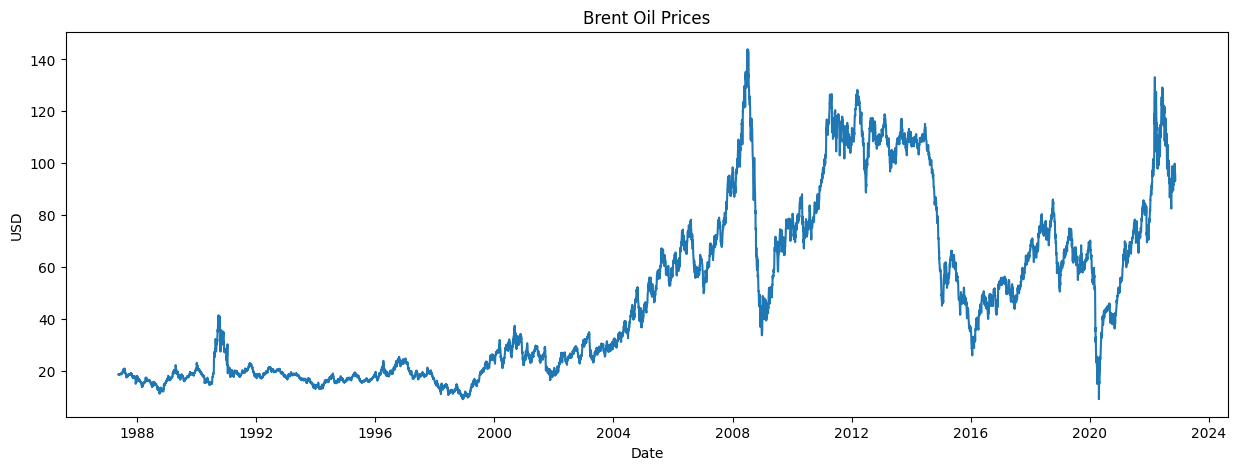

In [5]:
plt.figure(figsize=(15,5))
plt.plot(df["Date"], df["Price"])
plt.title("Brent Oil Prices")
plt.xlabel("Date")
plt.ylabel("USD")
plt.show()

In [6]:
df["Log_Return"] = np.log(df["Price"]).diff()

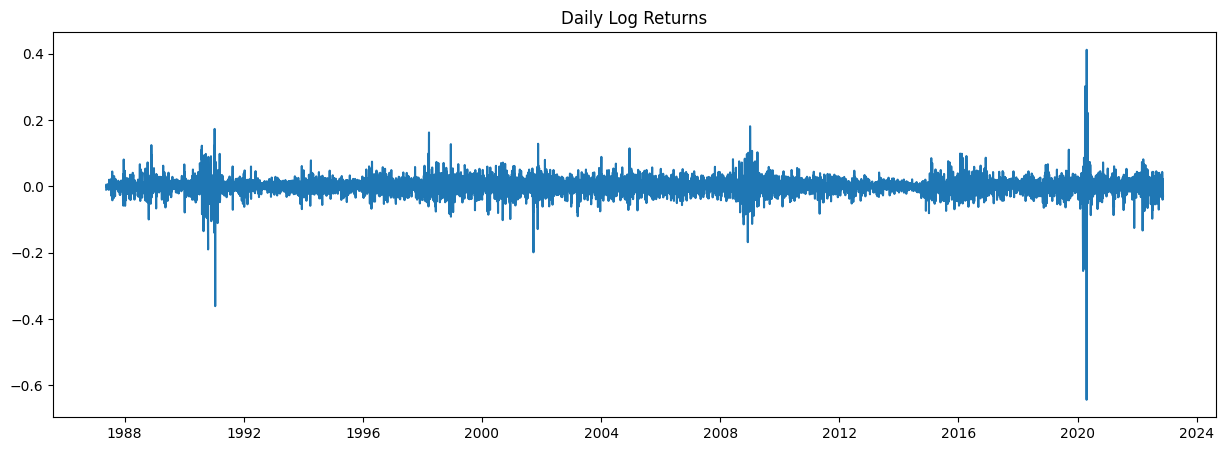

In [7]:
plt.figure(figsize=(15,5))
plt.plot(df["Date"], df["Log_Return"])
plt.title("Daily Log Returns")
plt.show()

## Time Series Properties

### Trend
The Brent crude oil price series exhibits a clear long-term trend with several periods of rapid increases and sharp declines. Rather than remaining constant over time, prices respond to major geopolitical events, economic crises, and changes in global oil supply and demand. These visible shifts suggest that the series contains structural changes, making it appropriate for change point analysis.

### Stationarity
The raw Brent oil price series is **non-stationary**, meaning its statistical properties, such as the mean and variance, change over time. Since many time series models assume stationarity, daily log returns are calculated to produce a more stable series for analysis. Log returns fluctuate around zero and are generally more suitable for statistical modeling.

### Volatility
The log return series shows periods of both low and high volatility. Large fluctuations tend to cluster together during periods of economic uncertainty or geopolitical crises, indicating that oil prices become significantly more volatile following major market events. This changing volatility further supports the use of models capable of identifying structural breaks in the data.

In [8]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Log_Return"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("The log returns are stationary.")
else:
    print("The log returns are not stationary.")

ADF Statistic: -16.427113494485894
p-value: 2.4985801611428892e-29
The log returns are stationary.


The ADF test indicates whether the log return series is stationary. Stationary data are more appropriate for statistical modeling because their statistical properties remain relatively stable over time.

## Understanding Change Point Models

### What is a Change Point Model?

A change point model is a statistical method used to identify points in time where the underlying behavior of a time series changes significantly. In this project, it is used to detect dates at which Brent oil prices exhibit structural breaks, such as shifts in their average level or overall behavior.

### Why Use a Change Point Model?

Brent oil prices are influenced by geopolitical conflicts, OPEC production decisions, financial crises, and global economic shocks. Instead of assuming that the statistical properties of the series remain constant throughout the entire period, a change point model allows different behaviors before and after significant events. This helps identify when important market changes occurred.

### Expected Outputs

The Bayesian change point analysis is expected to produce:

- Estimated date(s) where structural changes occurred.
- Estimated parameters before and after each detected change point (such as the mean price).
- Posterior probability distributions that quantify uncertainty in the estimated change point locations.
- Evidence that can be compared with known geopolitical and economic events.

### Limitations

Although a detected change point may occur near a major historical event, this does **not** prove that the event caused the price change. Multiple events may occur within a short period, and other unobserved economic factors may also influence oil prices. Therefore, the analysis identifies statistical associations rather than establishing causal relationships.